In [1]:
import os
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

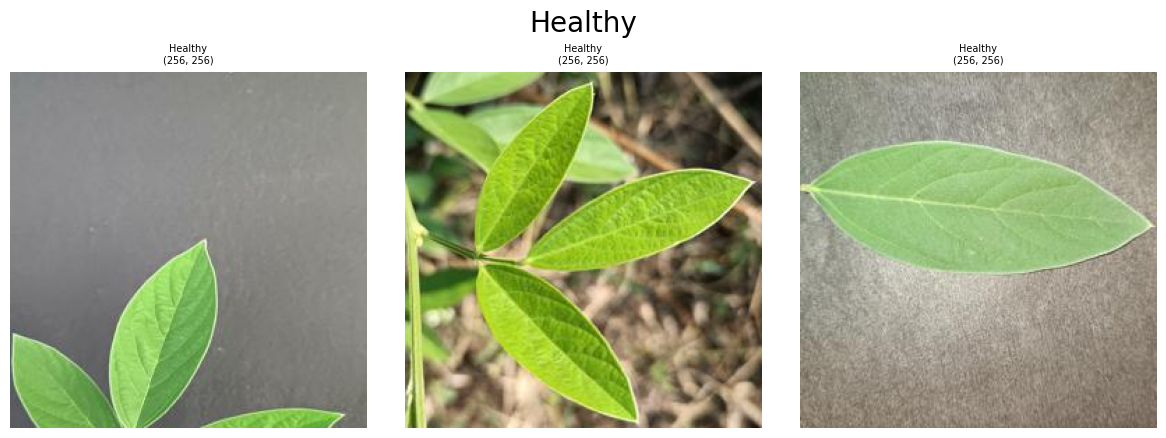

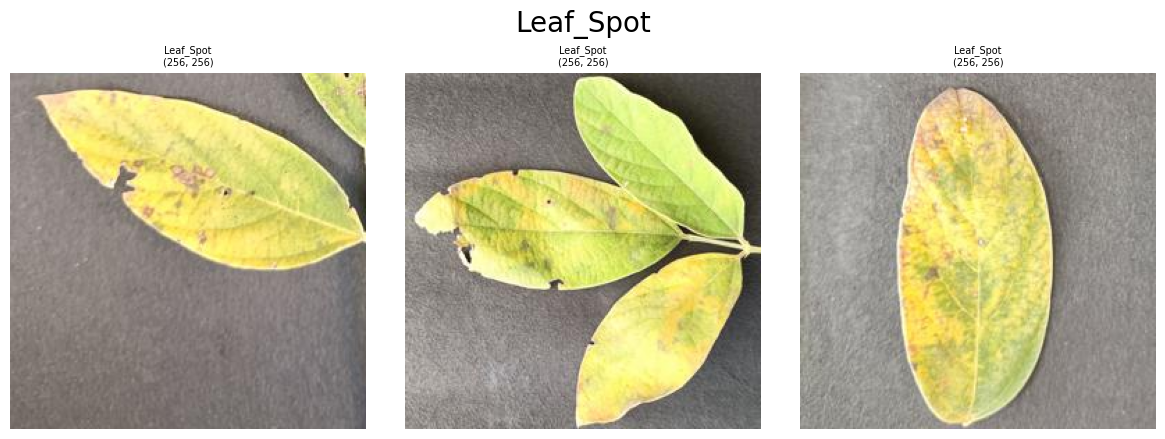

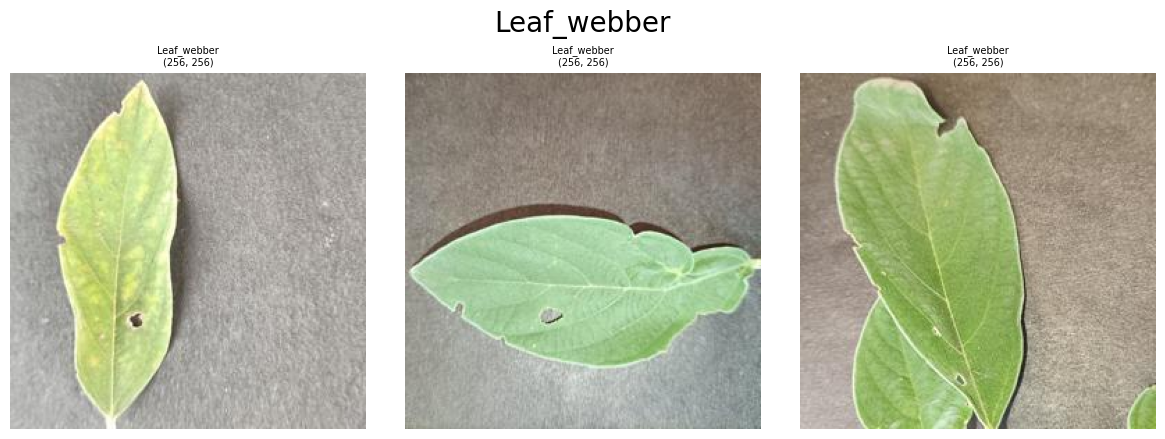

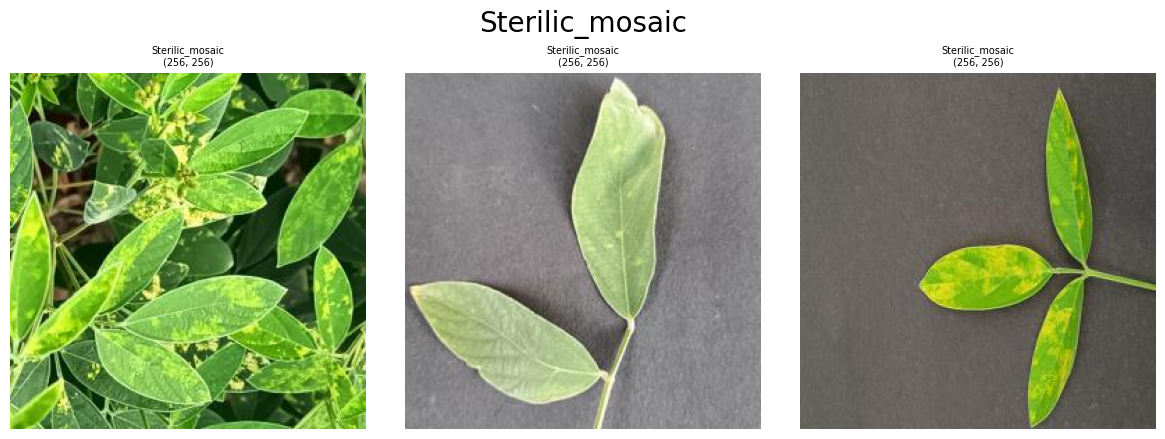

In [2]:
base_dir = "/Users/anushkaroy17/CBAM-ResGANet/PPLD"
classes = ["Healthy", "Leaf_Spot", "Leaf_webber", "Sterilic_mosaic"]

num_images = 3

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    images = os.listdir(class_path)
    
    selected_images = random.sample(images, min(num_images, len(images)))
    
    plt.figure(figsize=(12, 12))
    plt.suptitle(cls, fontsize=20)
    
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        shape_text = img.shape[:2]           
        
    
        
        plt.subplot(3, 3, i+1) 
        plt.imshow(img)
        plt.title(f"{cls}\n{shape_text}", fontsize=7)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [3]:
data_dir = "/Users/anushkaroy17/CBAM-ResGANet/PPLD"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])  # ResNet normalization
])

test_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(root=f"{data_dir}", transform=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = test_val_transforms
test_dataset.dataset.transform = test_val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Classes: ['Healthy', 'Leaf_Spot', 'Leaf_webber', 'Sterilic_mosaic']
Number of classes: 4
Train: 778, Val: 97, Test: 98


In [4]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(device)

mps


Shapes -> X_train: (778, 512), X_val: (97, 512), X_test: (98, 512)
Number of classes: 4


/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:41:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Train Acc: 0.9576 | Val Acc: 0.7010 | Test Acc: 0.7449

Classification Report :
                 precision    recall  f1-score   support

        Healthy       0.94      0.89      0.91        18
      Leaf_Spot       0.67      0.79      0.72        38
    Leaf_webber       0.95      0.90      0.92        20
Sterilic_mosaic       0.53      0.41      0.46        22

       accuracy                           0.74        98
      macro avg       0.77      0.75      0.76        98
   weighted avg       0.74      0.74      0.74        98



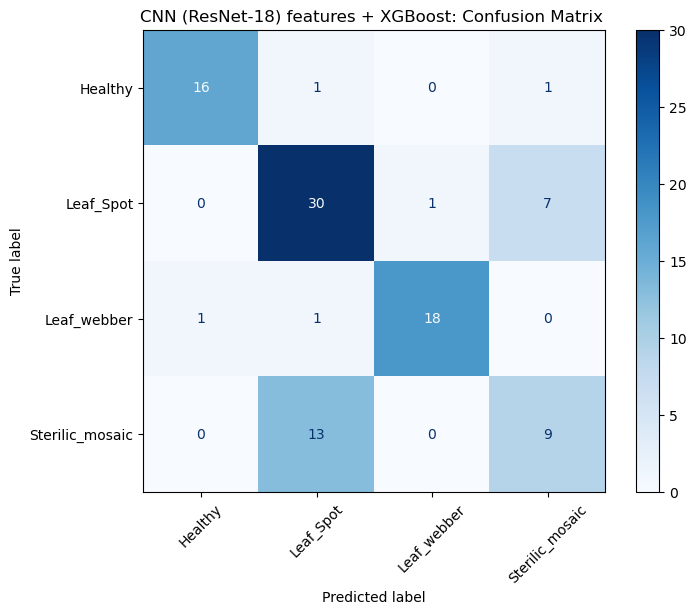

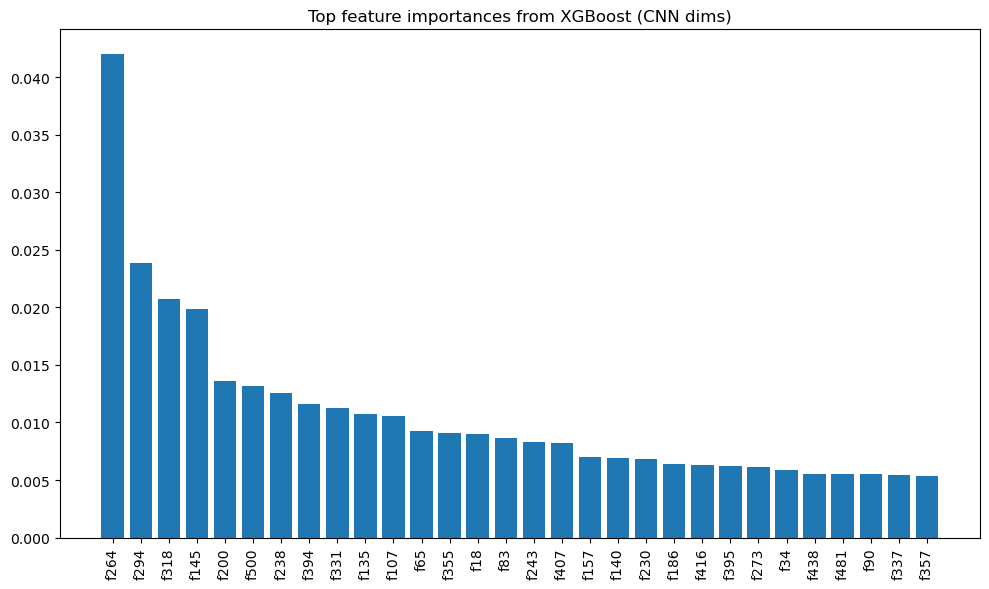

In [5]:

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet.parameters():
    param.requires_grad = False

in_features = resnet.fc.in_features
resnet.fc = nn.Identity()

resnet = resnet.to(device)
resnet.eval()
def extract_features(model, dataloader, device):
    model.eval()
    features_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            feats = model(imgs)                      # shape: (batch_size, feat_dim)
            feats = feats.cpu().numpy()
            lbls = labels.cpu().numpy()
            features_list.append(feats)
            labels_list.append(lbls)
    X = np.vstack(features_list)
    y = np.concatenate(labels_list)
    return X, y

X_train, y_train = extract_features(resnet, train_loader, device)
X_val, y_val = extract_features(resnet, val_loader, device)
X_test, y_test = extract_features(resnet, test_loader, device)

X_train, y_train = shuffle(X_train, y_train, random_state=42)

print(f"Shapes -> X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

pipeline = make_pipeline(StandardScaler(), xgb_clf)

pipeline.fit(X_train, y_train)

y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}\n")

print("Classification Report :")
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("CNN (ResNet-18) features + XGBoost: Confusion Matrix ")
plt.show()

fitted_xgb = pipeline.named_steps['xgbclassifier']

importances = fitted_xgb.feature_importances_ 
feat_idxs = np.argsort(importances)[::-1]

top_k = min(30, len(importances))
top_idx = feat_idxs[:top_k]
plt.figure(figsize=(10, 6))
plt.bar(range(top_k), importances[top_idx])
plt.xticks(range(top_k), [f"f{ix}" for ix in top_idx], rotation=90)
plt.title("Top feature importances from XGBoost (CNN dims)")
plt.tight_layout()
plt.show()


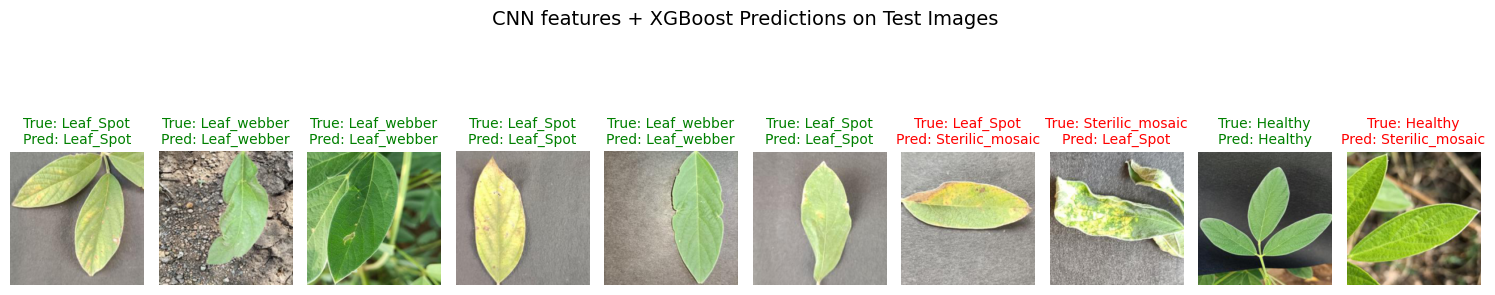

In [6]:

n_samples = 10
indices = random.sample(range(len(test_dataset)), n_samples)
resnet.eval()
resnet.to(device)

plt.figure(figsize=(15, 4))
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std  = np.array([0.229, 0.224, 0.225])

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]         # img is normalized tensor, shape (C,H,W)
    img_display = img.cpu().permute(1, 2, 0).numpy()    # H,W,C
    img_display = (img_display * imagenet_std) + imagenet_mean
    img_display = np.clip(img_display, 0, 1)

    img_input = img.unsqueeze(0).to(device)   # shape (1,C,H,W)

    with torch.no_grad():
        feats = resnet(img_input)             # shape (1, feat_dim) tensor on device (or cpu)
    feats_np = feats.cpu().numpy()            # shape (1, feat_dim)


    pred_label_idx = pipeline.predict(feats_np)[0]
    predicted_label = class_names[pred_label_idx]
    true_label = class_names[label]

    ax = plt.subplot(1, n_samples, i + 1)
    plt.imshow(img_display)
    title_color = "green" if true_label == predicted_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {predicted_label}", color=title_color, fontsize=10)
    ax.axis("off")

plt.suptitle("CNN features + XGBoost Predictions on Test Images", fontsize=14)
plt.tight_layout()
plt.show()
